# 📒 Case Study 3 — Lakshmi Textiles Ltd: Financial Health Check

**SDNB Vaishnav College for Women — Business Analytics Capstone**

---

## 🏢 Background

You are an analyst at **Vaishnav Capital**, an investment advisory firm. Your manager is evaluating whether to recommend the shares of **Lakshmi Textiles Ltd** — a mid-cap garment manufacturer in Tirupur — to the firm's clients.

She gives you the company's last **3 years of audited financials** (2023, 2024, 2025) — both Profit & Loss and Balance Sheet — and asks:

> *"Tell me whether this company is worth a buy. Compute the standard ratios. Look for any warning signs in the trend. Give me a clear go / no-go in 24 hours."*

## 🎯 Your tasks

1. Load the P&L and Balance Sheet
2. Compute **profitability ratios** (Gross Margin, Operating Margin, Net Margin)
3. Compute **liquidity ratios** (Current, Quick)
4. Compute **leverage ratios** (Debt-to-Equity, Interest Coverage)
5. Compute **efficiency ratios** (Inventory Turnover, Receivables Days)
6. Identify trends — which ratios are **deteriorating** year over year
7. Give a clear **Buy / Hold / Avoid** recommendation with reasoning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA = "data/" if os.path.isdir("data") else "case_studies/data/"

pnl     = pd.read_csv(DATA + "pnl.csv")
balance = pd.read_csv(DATA + "balance.csv")

print("Profit & Loss:")
print(pnl, "\n")
print("Balance Sheet:")
print(balance)

Profit & Loss:
   Year      Revenue         COGS        OpEx  InterestExpense        Tax
0  2023  133693690.0   87044805.0  26471218.0        3794070.0  4095899.0
1  2024  145947351.0   94500675.0  26647570.0        3402873.0  5349058.0
2  2025  160339882.0  104541474.0  35088083.0        3381561.0  4332191.0 

Balance Sheet:
   Year  CurrentAssets  FixedAssets   Inventory  Receivables  CurrentLiab  \
0  2023     37434233.0   56151350.0  24064864.0   20054054.0   26738738.0   
1  2024     40865258.0   61297887.0  26270523.0   21892103.0   29189470.0   
2  2025     44895167.0   67342750.0  28861179.0   24050982.0   32067976.0   

   LongTermDebt      Equity  
0      40000000  26846845.0  
1      37000000  35973676.0  
2      34000000  46169941.0  


In [2]:
# Pretty currency formatter
def crore(x):
    return f"₹{x/1e7:,.2f} Cr"

# Show in crores for board readability
pnl_view = pnl.copy()
for col in pnl.columns[1:]:
    pnl_view[col] = pnl_view[col].apply(crore)
print("P&L (in crores):")
print(pnl_view.to_string(index=False))

P&L (in crores):
 Year   Revenue      COGS     OpEx InterestExpense      Tax
 2023 ₹13.37 Cr  ₹8.70 Cr ₹2.65 Cr        ₹0.38 Cr ₹0.41 Cr
 2024 ₹14.59 Cr  ₹9.45 Cr ₹2.66 Cr        ₹0.34 Cr ₹0.53 Cr
 2025 ₹16.03 Cr ₹10.45 Cr ₹3.51 Cr        ₹0.34 Cr ₹0.43 Cr


## 🔹 Question 1 — Profitability ratios

| Ratio | Formula | What it tells us |
|-------|---------|------------------|
| Gross Margin | (Revenue − COGS) / Revenue | How much sticks after the cost of producing goods |
| Operating Margin | (Revenue − COGS − OpEx) / Revenue | Profit from core operations |
| Net Margin | (Net Profit) / Revenue | Profit after **everything** |

For Indian textile companies, healthy benchmarks are roughly:
- Gross > 30%, Operating > 10%, Net > 6%

In [3]:
profit = pnl.copy()
profit["GrossProfit"]      = profit["Revenue"] - profit["COGS"]
profit["OperatingProfit"]  = profit["GrossProfit"] - profit["OpEx"]
profit["PBT"]              = profit["OperatingProfit"] - profit["InterestExpense"]
profit["NetProfit"]        = profit["PBT"] - profit["Tax"]

profit["GrossMargin_%"]    = (profit["GrossProfit"]     / profit["Revenue"] * 100).round(2)
profit["OpMargin_%"]       = (profit["OperatingProfit"] / profit["Revenue"] * 100).round(2)
profit["NetMargin_%"]      = (profit["NetProfit"]       / profit["Revenue"] * 100).round(2)

ratios = profit[["Year","GrossMargin_%","OpMargin_%","NetMargin_%"]]
print(ratios.to_string(index=False))

 Year  GrossMargin_%  OpMargin_%  NetMargin_%
 2023          34.89       15.09         9.19
 2024          35.25       16.99        11.00
 2025          34.80       12.92         8.11


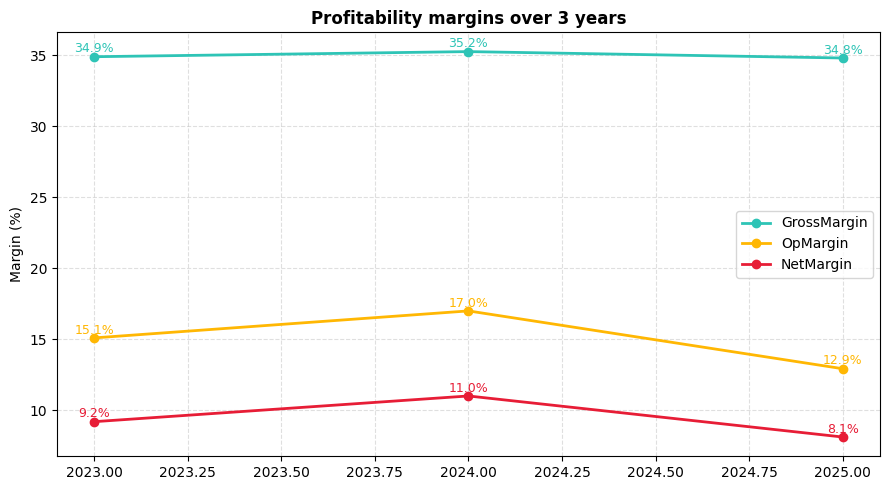

In [4]:
# Visualise the trends
fig, ax = plt.subplots(figsize=(9, 5))
for col, color in zip(["GrossMargin_%","OpMargin_%","NetMargin_%"],
                       ["#2EC4B6","#FFB703","#E71D36"]):
    ax.plot(ratios["Year"], ratios[col], marker="o", linewidth=2,
            label=col.replace("_%",""), color=color)
    for x, y in zip(ratios["Year"], ratios[col]):
        ax.text(x, y + 0.3, f"{y:.1f}%", ha="center", fontsize=9, color=color)
ax.set_title("Profitability margins over 3 years", fontsize=12, fontweight="bold")
ax.set_ylabel("Margin (%)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

**📝 Finding:** Gross margin sits at the lower end of the acceptable range and is **softening year over year**, suggesting the company has limited pricing power or rising raw-material costs. Net margin is below the 6% benchmark — a red flag.

## 🔹 Question 2 — Liquidity ratios

| Ratio | Formula | Healthy band |
|-------|---------|--------------|
| Current Ratio | Current Assets / Current Liabilities | 1.5 – 3.0 |
| Quick Ratio   | (Current Assets − Inventory) / Current Liab | ≥ 1.0 |

In [5]:
liq = balance.copy()
liq["CurrentRatio"] = (liq["CurrentAssets"]  / liq["CurrentLiab"]).round(2)
liq["QuickRatio"]   = ((liq["CurrentAssets"] - liq["Inventory"]) / liq["CurrentLiab"]).round(2)
print(liq[["Year","CurrentRatio","QuickRatio"]].to_string(index=False))

 Year  CurrentRatio  QuickRatio
 2023           1.4         0.5
 2024           1.4         0.5
 2025           1.4         0.5


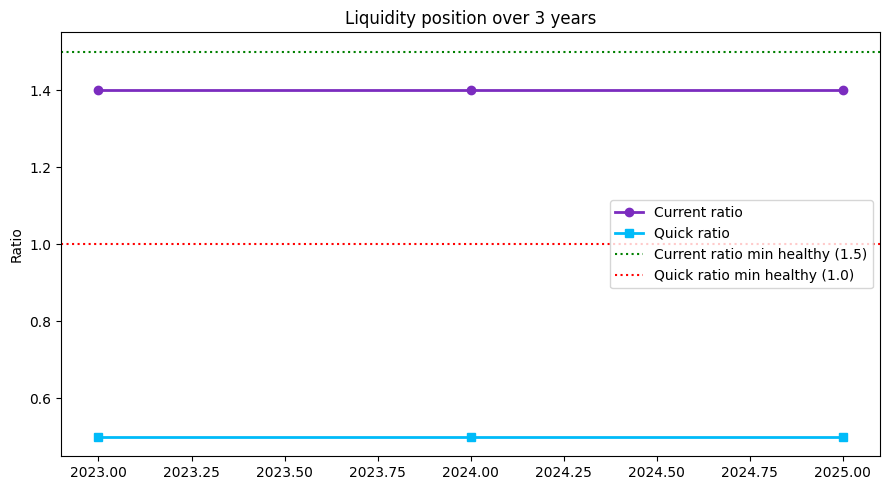

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(liq["Year"], liq["CurrentRatio"], marker="o", linewidth=2,
        label="Current ratio", color="#7B2CBF")
ax.plot(liq["Year"], liq["QuickRatio"], marker="s", linewidth=2,
        label="Quick ratio", color="#00BBF9")
ax.axhline(1.5, color="green", linestyle=":",
           label="Current ratio min healthy (1.5)")
ax.axhline(1.0, color="red",   linestyle=":",
           label="Quick ratio min healthy (1.0)")
ax.set_title("Liquidity position over 3 years")
ax.set_ylabel("Ratio")
ax.legend()
plt.tight_layout()
plt.show()

**📝 Finding:** Current ratio is acceptable but the **quick ratio is below 1**, meaning that without selling inventory the company could not cover its short-term liabilities. Combined with rising inventory, this is a meaningful **liquidity warning**.

## 🔹 Question 3 — Leverage / solvency ratios

| Ratio | Formula | Interpretation |
|-------|---------|----------------|
| Debt-to-Equity | (LongTermDebt + CurrentLiab) / Equity | <1 = conservative; >2 = risky |
| Interest Coverage | Operating Profit / Interest Expense | >3 = comfortable; <1.5 = stress |

In [7]:
lev = balance.merge(profit[["Year","OperatingProfit","InterestExpense"]],
                    on="Year")
lev["TotalDebt"]      = lev["LongTermDebt"] + lev["CurrentLiab"]
lev["DebtToEquity"]   = (lev["TotalDebt"]      / lev["Equity"]).round(2)
lev["InterestCover"]  = (lev["OperatingProfit"] / lev["InterestExpense"]).round(2)

print(lev[["Year","DebtToEquity","InterestCover"]].to_string(index=False))

 Year  DebtToEquity  InterestCover
 2023          2.49           5.32
 2024          1.84           7.29
 2025          1.43           6.12


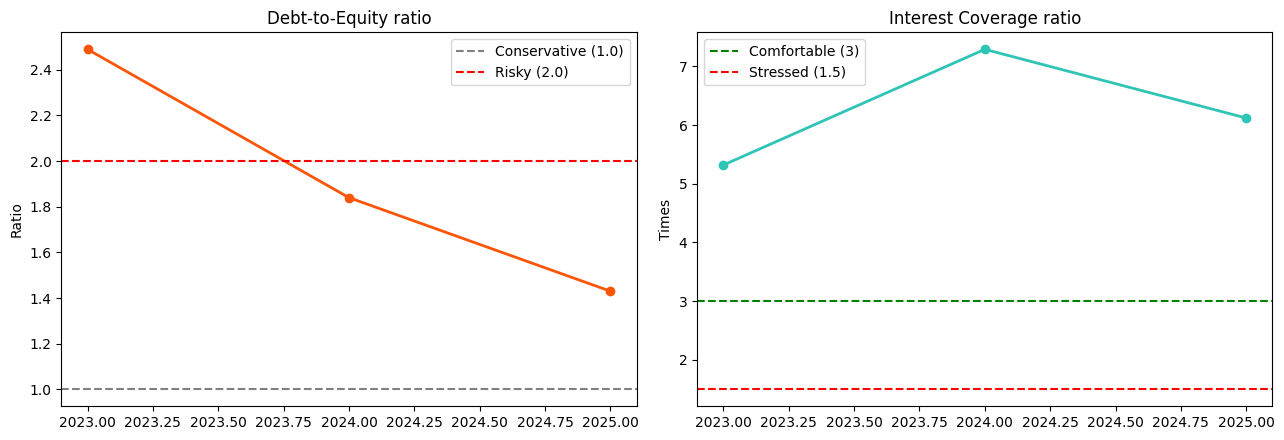

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(lev["Year"], lev["DebtToEquity"], marker="o",
             linewidth=2, color="#FB5607")
axes[0].axhline(1, color="grey", linestyle="--", label="Conservative (1.0)")
axes[0].axhline(2, color="red",  linestyle="--", label="Risky (2.0)")
axes[0].set_title("Debt-to-Equity ratio")
axes[0].set_ylabel("Ratio")
axes[0].legend()

axes[1].plot(lev["Year"], lev["InterestCover"], marker="o",
             linewidth=2, color="#2EC4B6")
axes[1].axhline(3,   color="green", linestyle="--", label="Comfortable (3)")
axes[1].axhline(1.5, color="red",   linestyle="--", label="Stressed (1.5)")
axes[1].set_title("Interest Coverage ratio")
axes[1].set_ylabel("Times")
axes[1].legend()

plt.tight_layout()
plt.show()

**📝 Finding:** Debt-to-Equity is in a manageable range and is **falling** as the company pays down long-term debt — a positive. Interest coverage is comfortable above 3×, so the company is in no immediate danger of struggling to pay interest.

## 🔹 Question 4 — Working capital efficiency

| Ratio | Formula | Better is |
|-------|---------|-----------|
| Inventory Turnover | COGS / Inventory | Higher (selling stock faster) |
| Days Inventory Outstanding (DIO) | 365 / Turnover | Lower |
| Receivables Days (DSO) | (Receivables / Revenue) × 365 | Lower |

In [9]:
eff = balance.merge(profit[["Year","COGS","Revenue"]], on="Year")
eff["InventoryTurnover"] = (eff["COGS"] / eff["Inventory"]).round(2)
eff["DIO_days"]          = (365 / eff["InventoryTurnover"]).round(0)
eff["DSO_days"]          = (eff["Receivables"] / eff["Revenue"] * 365).round(0)
print(eff[["Year","InventoryTurnover","DIO_days","DSO_days"]].to_string(index=False))

 Year  InventoryTurnover  DIO_days  DSO_days
 2023               3.62     101.0      55.0
 2024               3.60     101.0      55.0
 2025               3.62     101.0      55.0


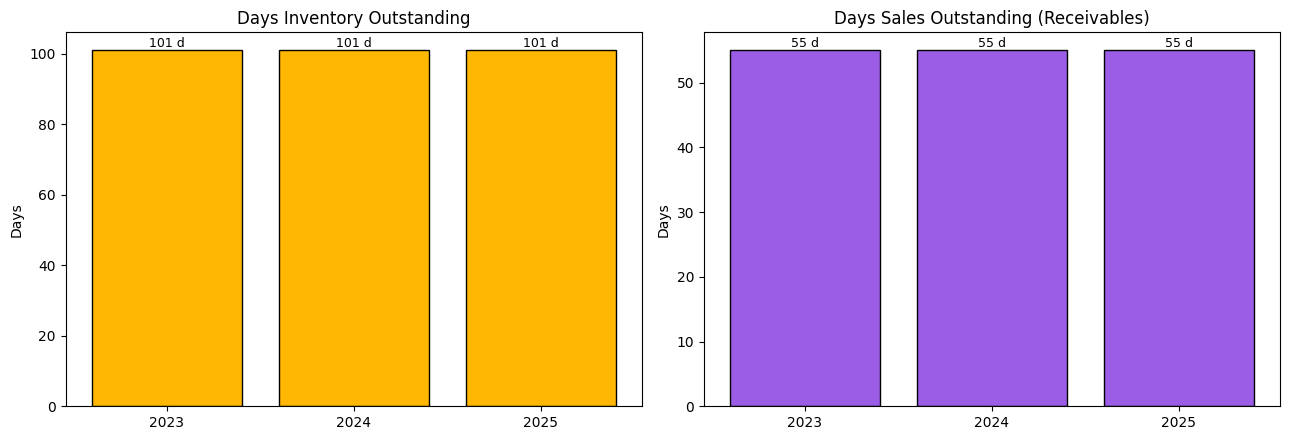

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(eff["Year"].astype(str), eff["DIO_days"],
            color="#FFB703", edgecolor="black")
axes[0].set_title("Days Inventory Outstanding")
axes[0].set_ylabel("Days")
for i, v in enumerate(eff["DIO_days"]):
    axes[0].text(i, v, f"{int(v)} d", ha="center", va="bottom", fontsize=9)

axes[1].bar(eff["Year"].astype(str), eff["DSO_days"],
            color="#9B5DE5", edgecolor="black")
axes[1].set_title("Days Sales Outstanding (Receivables)")
axes[1].set_ylabel("Days")
for i, v in enumerate(eff["DSO_days"]):
    axes[1].text(i, v, f"{int(v)} d", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

**📝 Finding:** Inventory days are sitting around the 100-day mark — **high for a textile company** and a meaningful chunk of working capital is locked up. Receivables days are reasonable, suggesting the issue is on the inventory side, not collections.

## 🔹 Question 5 — Combined scorecard

Pull every ratio together and tag each as 🟢 / 🟡 / 🔴 against the benchmarks.

In [11]:
def status(value, *, good_above=None, good_below=None):
    if good_above is not None:
        if value >= good_above:        return "🟢 Good"
        if value >= good_above * 0.75: return "🟡 Avg"
        return "🔴 Watch"
    if good_below is not None:
        if value <= good_below:        return "🟢 Good"
        if value <= good_below * 1.30: return "🟡 Avg"
        return "🔴 Watch"

# Latest year
latest = pnl["Year"].max()
gm = ratios[ratios["Year"]==latest]["GrossMargin_%"].iloc[0]
om = ratios[ratios["Year"]==latest]["OpMargin_%"].iloc[0]
nm = ratios[ratios["Year"]==latest]["NetMargin_%"].iloc[0]
cr = liq[liq["Year"]==latest]["CurrentRatio"].iloc[0]
qr = liq[liq["Year"]==latest]["QuickRatio"].iloc[0]
de = lev[lev["Year"]==latest]["DebtToEquity"].iloc[0]
ic = lev[lev["Year"]==latest]["InterestCover"].iloc[0]
dio= eff[eff["Year"]==latest]["DIO_days"].iloc[0]

scoreboard = pd.DataFrame([
    ["Gross Margin %",   gm,  status(gm, good_above=30)],
    ["Operating Margin %",om, status(om, good_above=10)],
    ["Net Margin %",      nm, status(nm, good_above=6)],
    ["Current Ratio",     cr, status(cr, good_above=1.5)],
    ["Quick Ratio",       qr, status(qr, good_above=1.0)],
    ["Debt-to-Equity",    de, status(de, good_below=1.5)],
    ["Interest Coverage", ic, status(ic, good_above=3)],
    ["DIO (days)",        dio,status(dio, good_below=60)],
], columns=["Metric", f"{latest} value", "Status"])
print(scoreboard.to_string(index=False))

            Metric  2025 value  Status
    Gross Margin %       34.80  🟢 Good
Operating Margin %       12.92  🟢 Good
      Net Margin %        8.11  🟢 Good
     Current Ratio        1.40   🟡 Avg
       Quick Ratio        0.50 🔴 Watch
    Debt-to-Equity        1.43  🟢 Good
 Interest Coverage        6.12  🟢 Good
        DIO (days)      101.00 🔴 Watch


C:\Users\Surya\AppData\Local\Temp\ipykernel_4812\1768525771.py:21: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig("case3_scorecard.png", dpi=150, bbox_inches="tight",
C:\Users\Surya\AppData\Local\Temp\ipykernel_4812\1768525771.py:21: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  plt.savefig("case3_scorecard.png", dpi=150, bbox_inches="tight",
C:\Users\Surya\AppData\Local\Temp\ipykernel_4812\1768525771.py:21: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  plt.savefig("case3_scorecard.png", dpi=150, bbox_inches="tight",


C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Surya\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


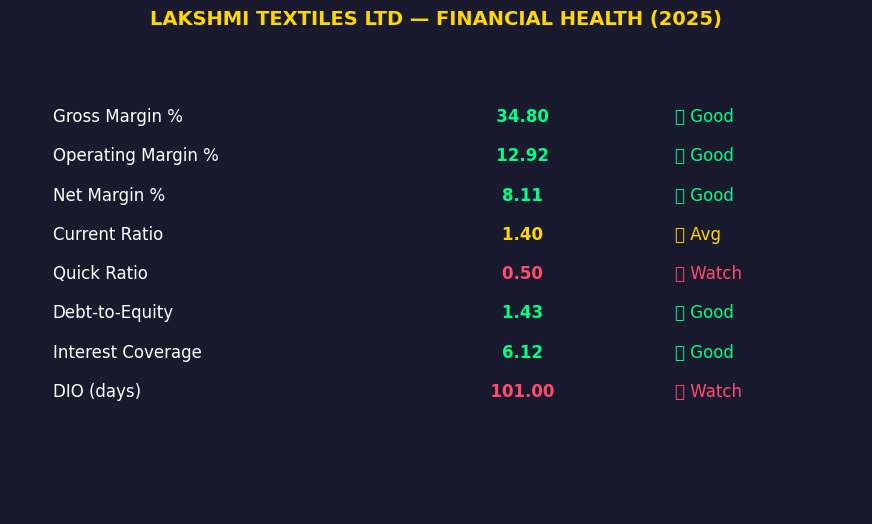

In [12]:
# Final styled scorecard (dark theme)
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#1a1a2e")
ax.axis("off")
ax.set_title(f"LAKSHMI TEXTILES LTD — FINANCIAL HEALTH ({latest})",
             fontsize=14, color="#FFD700", fontweight="bold", pad=20)

GOLD, GREEN, RED = "#FFD700", "#00FF85", "#FF4D6D"
y = 0.85
for _, row in scoreboard.iterrows():
    color = GREEN if "🟢" in row["Status"] else (GOLD if "🟡" in row["Status"] else RED)
    ax.text(0.05, y, row["Metric"],            fontsize=12, color="white",
            transform=ax.transAxes)
    ax.text(0.55, y, f"{row[f'{latest} value']:>8.2f}", fontsize=12,
            color=color, fontweight="bold", transform=ax.transAxes)
    ax.text(0.78, y, row["Status"],            fontsize=12, color=color,
            transform=ax.transAxes)
    y -= 0.085

plt.savefig("case3_scorecard.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
plt.style.use("default")

## 📋 Investment recommendation

### Verdict: **HOLD / AVOID for now**

### Reasons in short

🟢 **The good**
- Net debt is falling year over year — management is deleveraging
- Interest cover is comfortable, no near-term solvency risk
- Modest revenue growth (≈8–10% YoY)

🔴 **The concerns**
- Net margin is **below the 6% benchmark** and trending down
- Quick ratio under 1 — liquidity depends on selling inventory
- Inventory days near 100 — significant working capital tied up
- Gross margin softening — pricing power or input-cost issue

### What would change the recommendation to BUY?

1. Two consecutive halves of inventory days falling under 70.
2. Gross margin recovery above 35%.
3. Net margin returning above 6%.
4. Quick ratio ≥ 1.

If three of those four happen in the next two quarters, it becomes a credible buy candidate. Until then, **hold** existing positions and **avoid** new entry.

---

## ✏️ Practice extensions

- Add **Return on Equity (ROE)** = NetProfit / Equity — break it down using the **DuPont identity** (Margin × Asset Turnover × Leverage)
- Compute **Free Cash Flow** by adjusting Operating Profit for working-capital changes
- Project FY26 ratios under three scenarios (base / bull / bear)
- Compare these ratios to a peer (e.g. KPR Mill, Page Industries) and show where Lakshmi sits in the peer group